<a href="https://colab.research.google.com/github/keerthana-25/neural_network_using_numpy_keras_pytorch/blob/main/pytorch_lightening.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
! pip install pytorch-lightning

INFO:lightning_fabric.utilities.seed:Seed set to 42
INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


┏━━━┳━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name ┃ Type       ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ net  │ Sequential │  9.0 K │ train │     0 │
└───┴──────┴────────────┴────────┴───────┴───────┘

Trainable params: 9.0 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 9.0 K                                                                                                
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 8                                                                                           
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)`
is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.

Output()

/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test_mse          │    0.2718028724193573     │
└───────────────────────────┴───────────────────────────┘

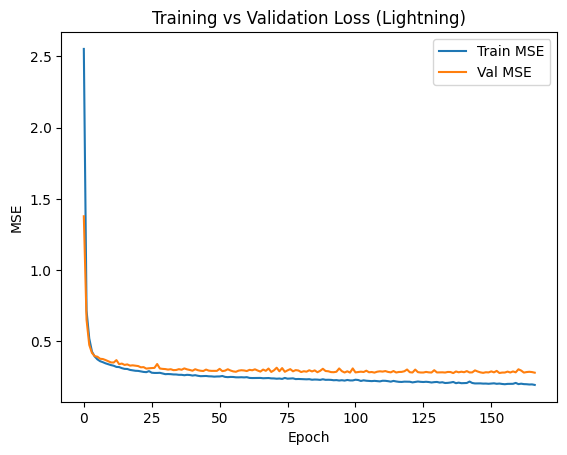

In [ ]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

import pytorch_lightning as pl
from pytorch_lightning.callbacks import EarlyStopping, ModelCheckpoint
from pytorch_lightning.loggers import CSVLogger

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt


class CaliforniaHousingDataModule(pl.LightningDataModule):
    def __init__(self, batch_size: int = 256, num_workers: int = 0):
        """
        Lightning DataModule for California Housing dataset.

        Args:
            batch_size: Mini-batch size for DataLoaders.
            num_workers: Number of DataLoader workers.
        """
        super().__init__()
        self.batch_size = batch_size
        self.num_workers = num_workers
        self.scaler = StandardScaler()

    def prepare_data(self) -> None:
        """Download/load data (called once on rank 0)."""
        fetch_california_housing()

    def setup(self, stage: str | None = None) -> None:
        """
        Split and preprocess data. Called by Lightning for fit/test phases.

        Args:
            stage: One of ("fit", "test", None).
        """
        data = fetch_california_housing()
        X = data.data
        y = data.target.reshape(-1, 1)

        # Train/test split
        X_train_full, X_test, y_train_full, y_test = train_test_split(
            X, y, test_size=0.2, random_state=42
        )

        # Train/val split
        X_train, X_val, y_train, y_val = train_test_split(
            X_train_full, y_train_full, test_size=0.2, random_state=42
        )

        # Fit scaler on train only
        X_train = self.scaler.fit_transform(X_train)
        X_val = self.scaler.transform(X_val)
        X_test = self.scaler.transform(X_test)

        # Tensors
        self.X_train = torch.tensor(X_train, dtype=torch.float32)
        self.y_train = torch.tensor(y_train, dtype=torch.float32)

        self.X_val = torch.tensor(X_val, dtype=torch.float32)
        self.y_val = torch.tensor(y_val, dtype=torch.float32)

        self.X_test = torch.tensor(X_test, dtype=torch.float32)
        self.y_test = torch.tensor(y_test, dtype=torch.float32)

    def train_dataloader(self) -> DataLoader:
        ds = TensorDataset(self.X_train, self.y_train)
        return DataLoader(
            ds, batch_size=self.batch_size, shuffle=True, num_workers=self.num_workers
        )

    def val_dataloader(self) -> DataLoader:
        ds = TensorDataset(self.X_val, self.y_val)
        return DataLoader(
            ds, batch_size=self.batch_size, shuffle=False, num_workers=self.num_workers
        )

    def test_dataloader(self) -> DataLoader:
        ds = TensorDataset(self.X_test, self.y_test)
        return DataLoader(
            ds, batch_size=self.batch_size, shuffle=False, num_workers=self.num_workers
        )


class DeepNNRegressor(pl.LightningModule):
    def __init__(self, input_size: int, lr: float = 1e-3):
        """
        Deep neural network regressor (LightningModule).

        Args:
            input_size: Number of input features.
            lr: Learning rate for Adam optimizer.
        """
        super().__init__()
        self.save_hyperparameters()

        self.net = nn.Sequential(
            nn.Linear(input_size, 64),
            nn.ReLU(),
            nn.Linear(64, 64),
            nn.ReLU(),
            nn.Linear(64, 64),
            nn.ReLU(),
            nn.Linear(64, 1),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Forward pass.

        Args:
            x: Input features tensor (batch, input_size).
        Returns:
            Predictions tensor (batch, 1).
        """
        return self.net(x)

    def _shared_step(self, batch: tuple[torch.Tensor, torch.Tensor], stage: str) -> torch.Tensor:
        """
        Compute loss for a given stage and log it.

        Args:
            batch: (X, y)
            stage: One of ("train", "val", "test")
        Returns:
            Loss tensor.
        """
        x, y = batch
        preds = self(x)
        loss = F.mse_loss(preds, y)

        # Log per-epoch averages (cleaner than per-step spam)
        self.log(f"{stage}_mse", loss, on_step=False, on_epoch=True, prog_bar=True)
        return loss

    def training_step(self, batch: tuple[torch.Tensor, torch.Tensor], batch_idx: int) -> torch.Tensor:
        return self._shared_step(batch, "train")

    def validation_step(self, batch: tuple[torch.Tensor, torch.Tensor], batch_idx: int) -> torch.Tensor:
        self._shared_step(batch, "val")

    def test_step(self, batch: tuple[torch.Tensor, torch.Tensor], batch_idx: int) -> torch.Tensor:
        self._shared_step(batch, "test")

    def configure_optimizers(self):
        """
        Configure optimizer (and optionally schedulers).

        Returns:
            Optimizer (or dict including scheduler).
        """
        return optim.Adam(self.parameters(), lr=self.hparams.lr)


# ---- run training ----
pl.seed_everything(42, workers=True)

dm = CaliforniaHousingDataModule(batch_size=256, num_workers=0)
dm.setup()

model = DeepNNRegressor(input_size=dm.X_train.shape[1], lr=1e-3)

logger = CSVLogger("lightning_logs", name="california_housing")

callbacks = [
    EarlyStopping(monitor="val_mse", mode="min", patience=30),
    ModelCheckpoint(monitor="val_mse", mode="min", save_top_k=1),
]

trainer = pl.Trainer(
    max_epochs=500,
    accelerator="auto",
    devices="auto",
    logger=logger,
    callbacks=callbacks,
    log_every_n_steps=10,
)

trainer.fit(model, datamodule=dm)
trainer.test(model, datamodule=dm)

# ---- plot losses from CSV logs ----
metrics_path = f"{logger.log_dir}/metrics.csv"
import pandas as pd

metrics = pd.read_csv(metrics_path)

train_curve = metrics.dropna(subset=["train_mse"])[["epoch", "train_mse"]]
val_curve = metrics.dropna(subset=["val_mse"])[["epoch", "val_mse"]]

plt.plot(train_curve["epoch"], train_curve["train_mse"], label="Train MSE")
plt.plot(val_curve["epoch"], val_curve["val_mse"], label="Val MSE")
plt.title("Training vs Validation Loss (Lightning)")
plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.legend()
plt.show()